# NB04 – Business Case Bericht
### CAS Information Engineering – Scripting Project
**Gruppe:** SC26_Gruppe_2 | **Mitglieder:** Patrik Neunteufel · Senthuran Elankeswaran · Cyril Saladin | **Datum:** Mai 2026

---
Bericht: Business Case Grid-Arbitrage mit Batteriespeichern.  
Charts werden aus `output/charts/` geladen (erzeugt durch NB03).

---
| [← NB03 Visualisierungen](03_Visualisierungen.ipynb) | [↑ Projektübersicht](00_Project_Overview.ipynb) | [→ NB05 Business Strategy](05_Business_Strategy.ipynb) |
|:---|:---:|---:|


*Charts werden aus `charts/` geladen (erzeugt durch NB3). Einzelplots sind grösser und direkt berichtstauglich.*


In [1]:
# ── Setup: Chart-Anzeige ─────────────────────────────────────────────────────
import os
import json as _json
import pandas as pd
from IPython.display import display, Image

# Zentrale Konfiguration laden
if os.path.exists('config.json'):
    with open('config.json') as _f:
        CFG = _json.load(_f)
else:
    CFG = {}  # Fallback: läuft ohne config.json

SZ_AKTIV     = CFG.get('gleichzeitigkeit_aktiv', 'realistisch')
DIR_INTER    = os.path.join('data', 'intermediate')
DIR_INTER_SZ = os.path.join(DIR_INTER, SZ_AKTIV)
CHARTS_DIR   = os.path.join('output', 'charts', SZ_AKTIV)

def show_chart(filename, caption='', width=950):
    path = os.path.join(CHARTS_DIR, filename)
    if not os.path.exists(path):
        print(f'Nicht vorhanden: {path} → NB3 zuerst ausführen.')
        return
    display(Image(filename=path, width=width))
    if caption:
        print(f'\n{caption}\n')

# Szenarien-Metadaten aus NB2 laden (enthält Gleichzeitigkeit-Einstellung)
SZ_FILE = os.path.join(DIR_INTER_SZ, 'netzentlastung_szenarien.csv')
_gz_mode = 'unbekannt'
_gz_rate = '?'
if os.path.exists(SZ_FILE):
    _df_sz = pd.read_csv(SZ_FILE)
    if 'gleichzeitigkeit' in _df_sz.columns:
        _gz_mode = _df_sz['gleichzeitigkeit'].iloc[0]
        _gz_rate = f"{_df_sz['rate_pct'].iloc[0]:.0f}%"
        print(f'Szenarien geladen — Gleichzeitigkeit: {_gz_mode} ({_gz_rate})')
    else:
        print('Szenarien geladen (Format ohne Gleichzeitigkeit-Spalte)')
else:
    print('netzentlastung_szenarien.csv nicht gefunden → NB2 zuerst ausführen')

charts = sorted(f for f in os.listdir(CHARTS_DIR) if f.endswith('.png')) \
         if os.path.exists(CHARTS_DIR) else []
print(f'{len(charts)} Charts verfügbar in charts/')
# -- Transfer: Ergebnisse aus transfer.json laden ----------------------------
_tf_path = 'transfer.json'
if os.path.exists(_tf_path) and os.path.getsize(_tf_path) > 0:
    TF      = _json.load(open(_tf_path))
    _dt     = TF.get('datenzeitraum', {})
    _sim    = TF.get('simulation', {})
    TF_N_YEARS  = _dt.get('n_years', None)
    TF_START    = _dt.get('start_date', 'unbekannt')
    TF_END      = _dt.get('end_date', 'unbekannt')
    TF_SPREAD   = _sim.get('spread_mean_eur_mwh', None)
    TF_ECON     = _sim.get('wirtschaftlichkeit', {})
    TF_HYB      = TF.get('hybrid_simulation', {}).get('ergebnisse', {})
    TF_KUER     = CFG.get('kuer_aktiv', {})   # aus config.json (SSOT)
    print(f"transfer.json: {TF_START} – {TF_END} ({TF_N_YEARS} Jahre) | Spread: {TF_SPREAD} EUR/MWh")
else:
    TF = {}; TF_N_YEARS = None; TF_START = TF_END = 'unbekannt'
    TF_SPREAD = None; TF_ECON = {}; TF_HYB = {}; TF_KUER = {}
    print('⚠️  transfer.json nicht gefunden — NB01/NB02 zuerst ausführen')


Szenarien geladen — Gleichzeitigkeit: realistisch (40%)
62 Charts verfügbar in charts/
transfer.json: 2023 – 2026 (3.246 Jahre) | Spread: 23.87 EUR/MWh


## 1. Einleitung

### Geschäftliches Problem

Die Schweiz steht vor einer doppelten Herausforderung: Einerseits soll der Anteil erneuerbarer Energien stark ausgebaut werden, andererseits müssen gleichzeitig die Netzstabilität und die Versorgungssicherheit gewährleistet bleiben. Erneuerbare Energien wie Photovoltaik und Wind produzieren Strom unregelmässig und verstärken die Schwankungen im Netz.

**Die Kernfrage dieses Projekts:** Können private und industrielle Batteriespeicher, die **unabhängig von einer Solaranlage** betrieben werden, durch gezieltes Laden bei Niedrigpreisen und Einspeisen bei Hochpreisen gleichzeitig wirtschaftlich rentabel sein **und** zur Netzentlastung beitragen?

Dieser Mechanismus wird als **Grid-Arbitrage** bezeichnet.

### Wer ist interessiert?

| Stakeholder | Interesse |
|-------------|-----------|
| Privathaushalte | Kostenersparnis durch günstigeres Laden, Zusatzeinnahmen |
| Gewerbebetriebe | Lastspitzenvermeidung + Arbitrage-Erlöse |
| Netzbetreiber (Swissgrid) | Weniger Netzausbaubedarf durch aggregierte Speicher |
| Politik / BFE | Datenbasis für Förderstrategien, Energiestrategie 2050 |
| Investoren | Portfolio-Optimierung mit Stromspeicher-Projekten |


## 2. Daten

### Verwendete Datensätze

**Datensatz 1: ENTSO-E Day-Ahead Spot-Preise (Schweiz)**  
Stündliche Day-Ahead Preise für die CH-Bietungszone (`10YCH-SWISSGRIDZ`) in EUR/MWh, 2023–2024. Quelle: [transparency.entsoe.eu](https://transparency.entsoe.eu)

**Datensatz 2: ENTSO-E Netzlast CH**  
Stündliche Systemlast des Schweizer Regelblocks [MW], gleiche Quelle und Zeitraum.

**Datensatz 3: ENTSO-E Grenzflüsse CH** *(optional)*  
Stündliche physikalische Flüsse auf allen CH-Grenzleitungen (DE/AT/IT/FR). Netto-Export negativ = CH importiert. Validiert den Business Case empirisch.

**Datensatz 4: BFE Elektrizitätsproduktionsanlagen**  
Geodaten aller registrierten Anlagen (322k). Für die räumliche Analyse in NB5. Quelle: [opendata.swiss](https://opendata.swiss/de/dataset/elektrizitatsproduktionsanlagen)


## 3. Methodik

### Dispatch-Modell

Die Batterie-Dispatch-Simulation verwendet ein tagesbasiertes Schwellenwertmodell:
- **Laden:** Wenn der aktuelle Preis unter dem 25. Perzentil des jeweiligen Tages liegt und der Ladezustand unter 95% ist
- **Einspeisen:** Wenn der aktuelle Preis über dem 75. Perzentil des Tages liegt und der Ladezustand über 5% ist
- **Idle:** Sonst — keine Aktion

Der Round-Trip-Wirkungsgrad beträgt 92% (realistischer Wert für Lithium-Ionen-Batterien).

### Simulierte Segmente

| Segment | Kapazität | Leistung | Stückzahl CH (Schätzung) |
|---------|-----------|----------|--------------------------|
| Privat | 10 kWh | 5 kW | 200'000 |
| Gewerbe | 100 kWh | 30 kW | 10'000 |
| Industrie | 1 MWh | 200 kW | 1'000 |
| Utility | 10 MWh | 1'000 kW | 100 |

### Wirtschaftlichkeitsrechnung

CAPEX-Annahmen (2024): Privat 400 EUR/kWh, Gewerbe 300 EUR/kWh, Industrie 220 EUR/kWh, Utility 180 EUR/kWh. Betriebskosten 1.5% des CAPEX pro Jahr. Nutzungsdauer 12 Jahre.


## 4. Ergebnisse

### 4.1 Spot-Preis-Struktur

Das Tages- und Saisonalprofil der Schweizer Day-Ahead Preise zeigt zwei klare Muster: **Tief im solaren Mittagsfenster (Frühjahr/Sommer)** und bei niedrigem Verbrauch (Nachtstunden), **hoch bei Morgen- und Abendspitze**. Die Heatmap zeigt den tiefsten Durchschnittspreis im Mittag der Sommermonate (Solar-Erzeugungsmaximum) und die höchste Volatilität in den Übergangsjahreszeiten.


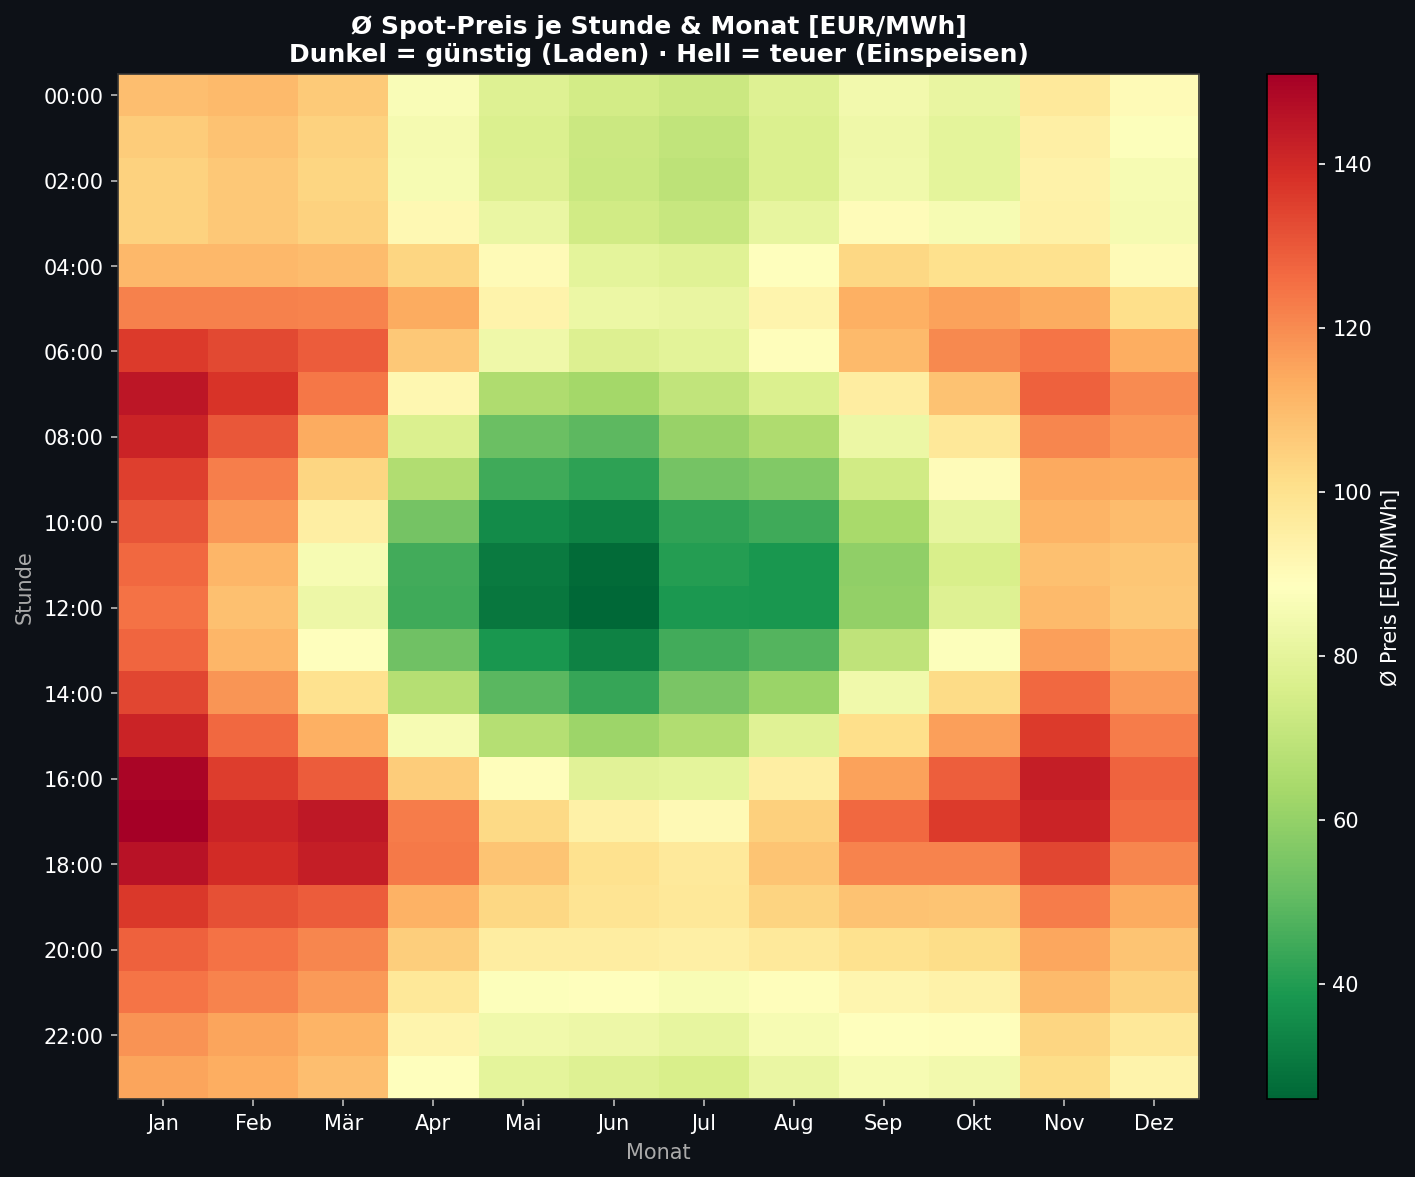


Chart 2: Ø Spot-Preis CH — Stunde × Monat 2023–2024



In [2]:
show_chart('nb03_heatmap_preis.png',
           'Chart 2: Ø Spot-Preis CH — Stunde × Monat 2023–2024', width=900)

### 4.2 Tagesprofil: Netzlast & Arbitrage-Fenster

Chart 3 zeigt die zeitliche Überlagerung von Netzlast und Preis: Das **Ladefenster (blau, ~09–13 Uhr)** fällt ins Solar-Mittagstief, wenn Preise und Netzlast tief sind. Das **Einspeisefenster (rot, ~15–20 Uhr)** trifft die Abendspitze — genau dann ist die Netzlast am höchsten und der Beitrag zur Netzentlastung am grössten.


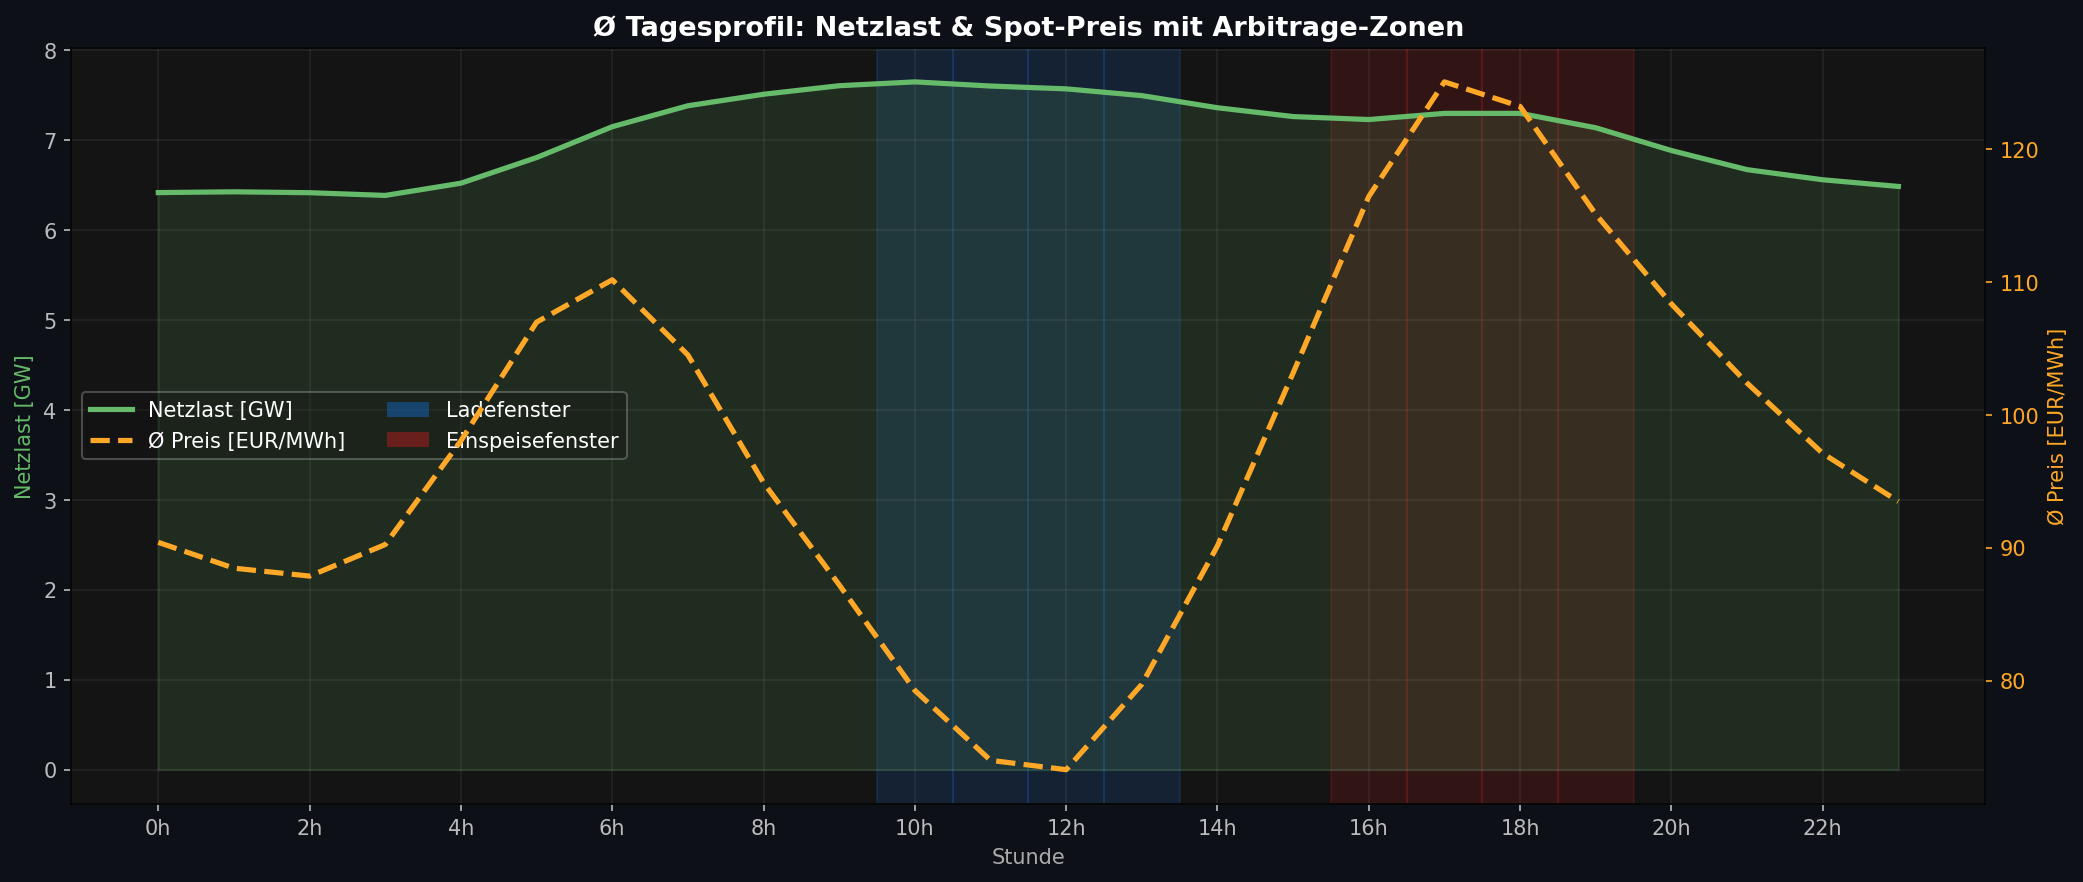


Chart 3: Ø Tagesprofil Netzlast & Spot-Preis mit Arbitrage-Fenstern



In [3]:
show_chart('nb03_tagesprofil_einzel.png',
           'Chart 3: Ø Tagesprofil Netzlast & Spot-Preis mit Arbitrage-Fenstern', width=900)

### 4.3 Wirtschaftlichkeit

Die folgenden Charts zeigen die Wirtschaftlichkeit aus vier Winkeln. Alle Zahlen basieren **ausschliesslich auf Arbitrage-Erlösen** — Regelenergiemarkt (FCR/aFRR), Peak-Shaving-Prämien und Erlösstacking sind nicht eingerechnet.

**Kernergebnis:** Kein Segment erreicht den Ziel-ROI von 5% p.a. bei reiner Arbitrage. Industrie liegt mit 2.3% am nächsten, Privat mit 0.6% am weitesten entfernt. Keines der Segmente erreicht den Break-Even innerhalb der modellierten 12 Jahre — auch auf 20 Jahre (Chart 1e) bleibt der kumulierte Cashflow negativ.


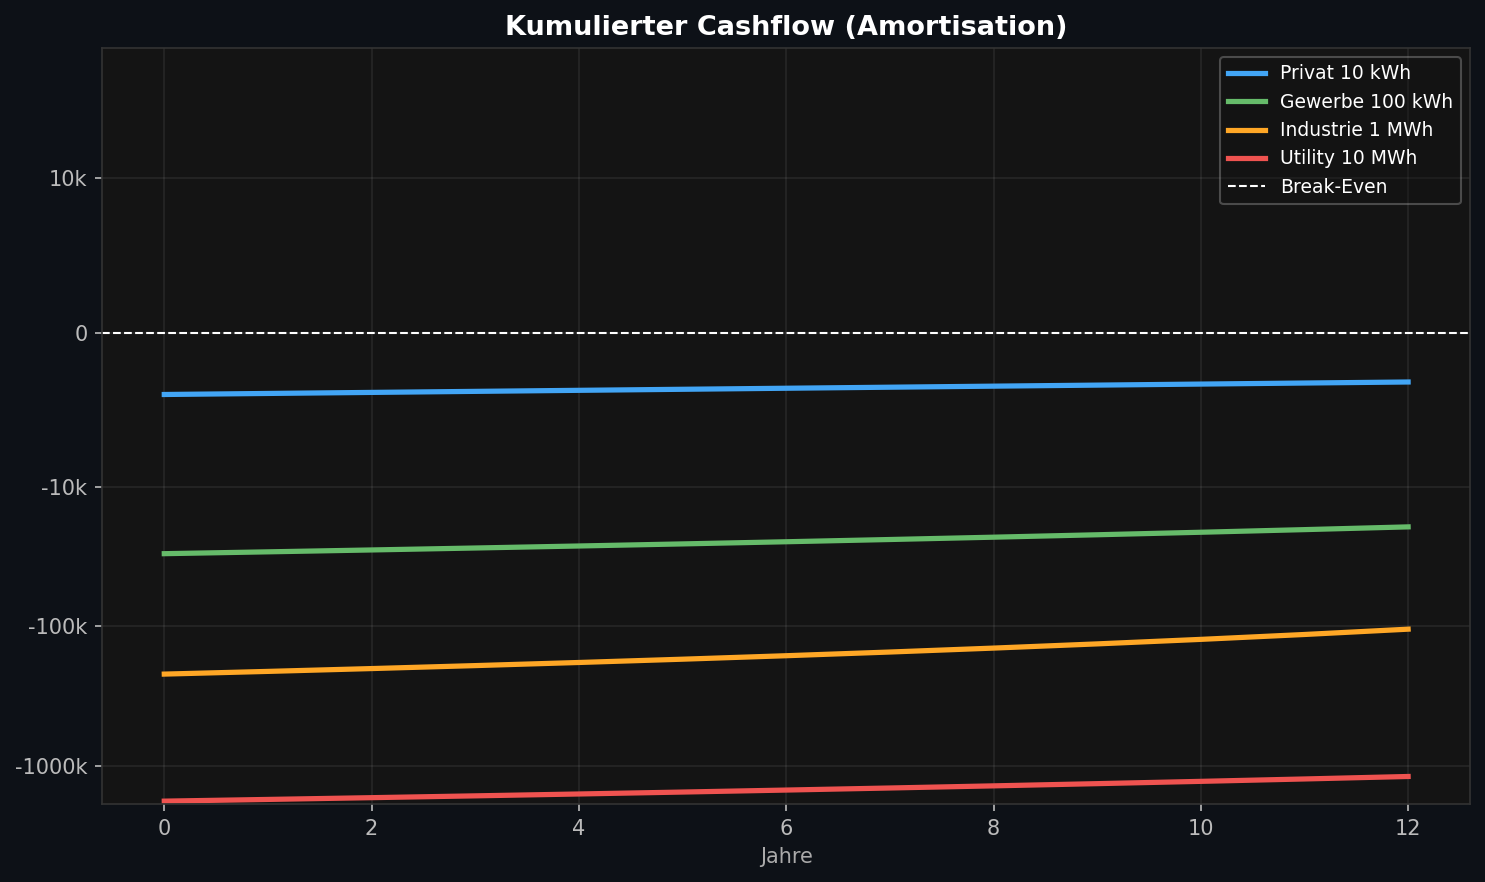


Amortisationskurven: kumulierter Cashflow über 12 Jahre



In [4]:
show_chart('nb03_amortisation.png',
           'Amortisationskurven: kumulierter Cashflow über 12 Jahre', width=900)

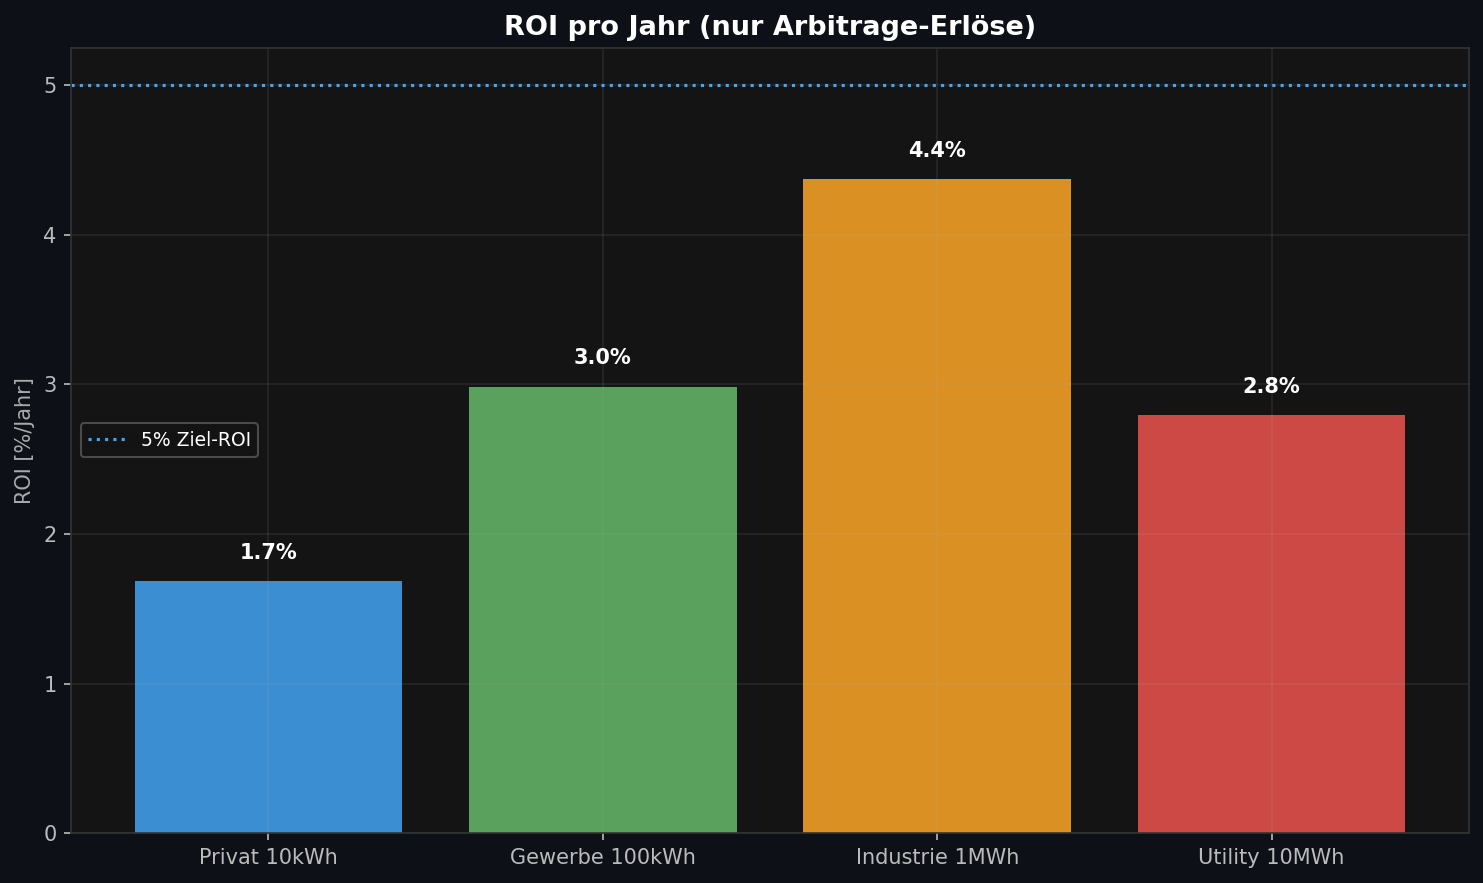


ROI pro Jahr nach Segment (nur Arbitrage-Erlöse)



In [5]:
show_chart('nb03_roi.png',
           'ROI pro Jahr nach Segment (nur Arbitrage-Erlöse)', width=900)

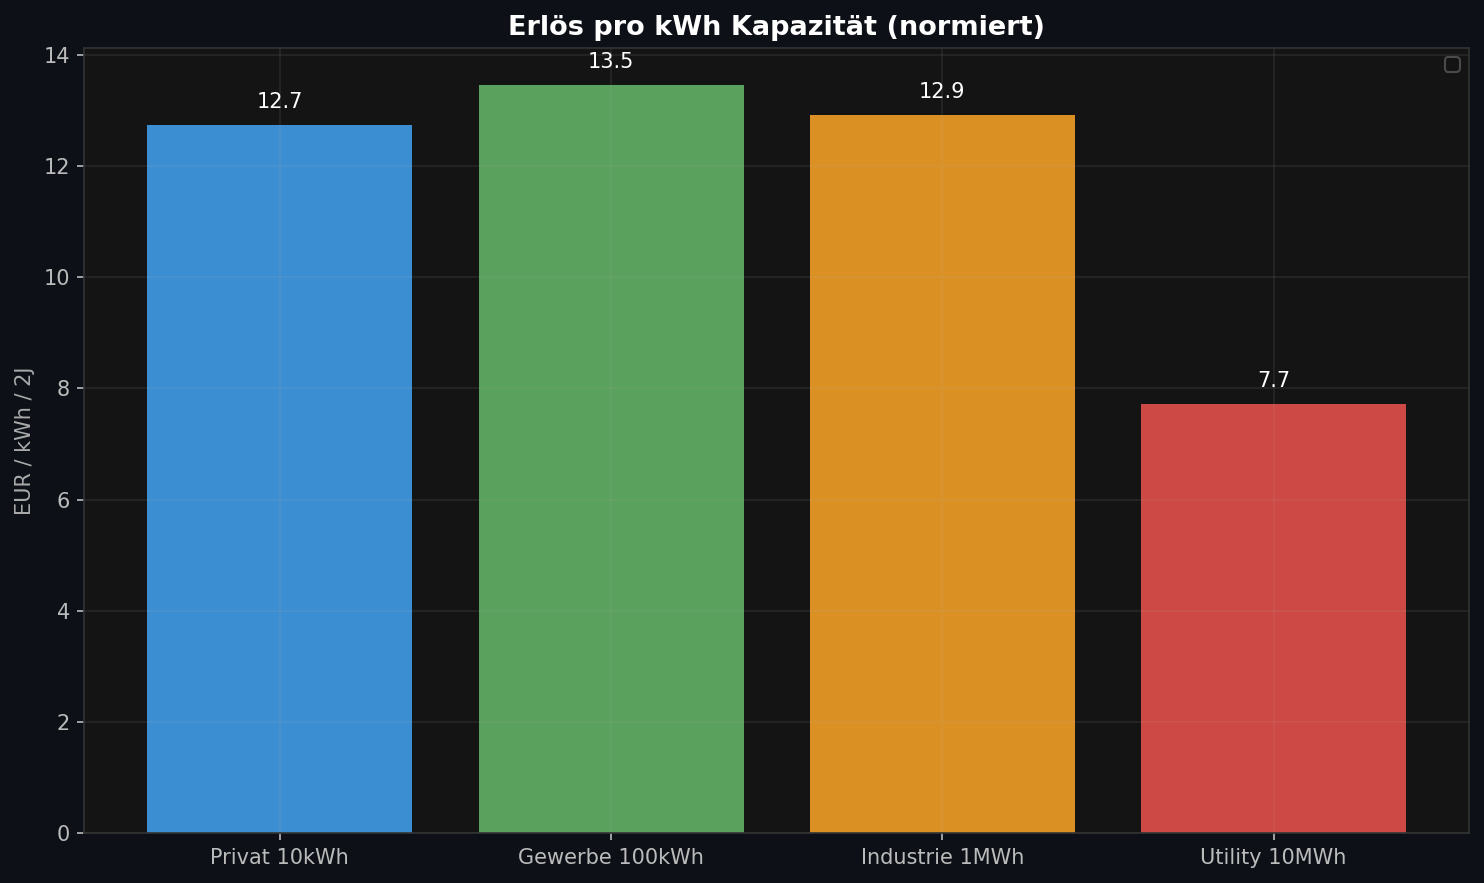


Erlös pro kWh Kapazität — normierter Segmentvergleich



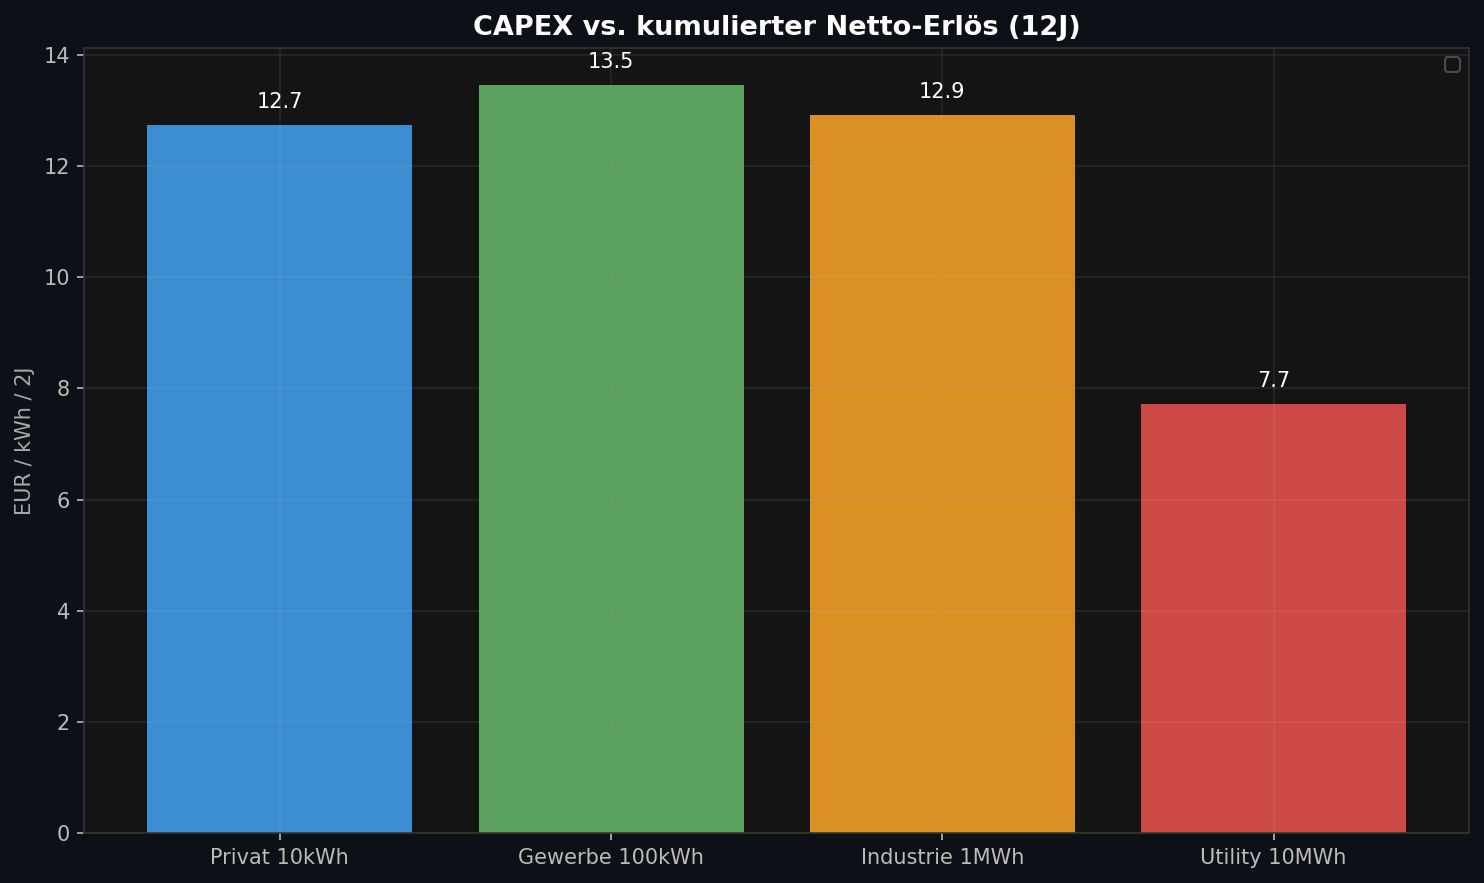


CAPEX vs. kumulierter Netto-Erlös (12 Jahre)



In [6]:
# Nebeneinander: Erlös/kWh und CAPEX vs. Ertrag
show_chart('nb03_erloese_kwh.png',
           'Erlös pro kWh Kapazität — normierter Segmentvergleich', width=900)
show_chart('nb03_capex_ertrag.png',
           'CAPEX vs. kumulierter Netto-Erlös (12 Jahre)', width=900)

### 4.4 Netzentlastungs-Potenzial

Aggregierte Batterien können die Schweizer Spitzenlast (Basis: 10.5 GW) messbar reduzieren. Die Wirkung steigt stark mit dem Rollout-Szenario: Von 1.3% (Moderat, 2027) bis 20.2% (Transformativ, 2035).

> **Gleichzeitigkeits-Annahme:** Die Ergebnisse basieren auf dem aktiven Szenario in `config.json → szenarien.gleichzeitigkeit_aktiv`. Zum Umschalten: Wert ändern → NB02 + NB03 neu ausführen → Charts aktualisieren sich automatisch.


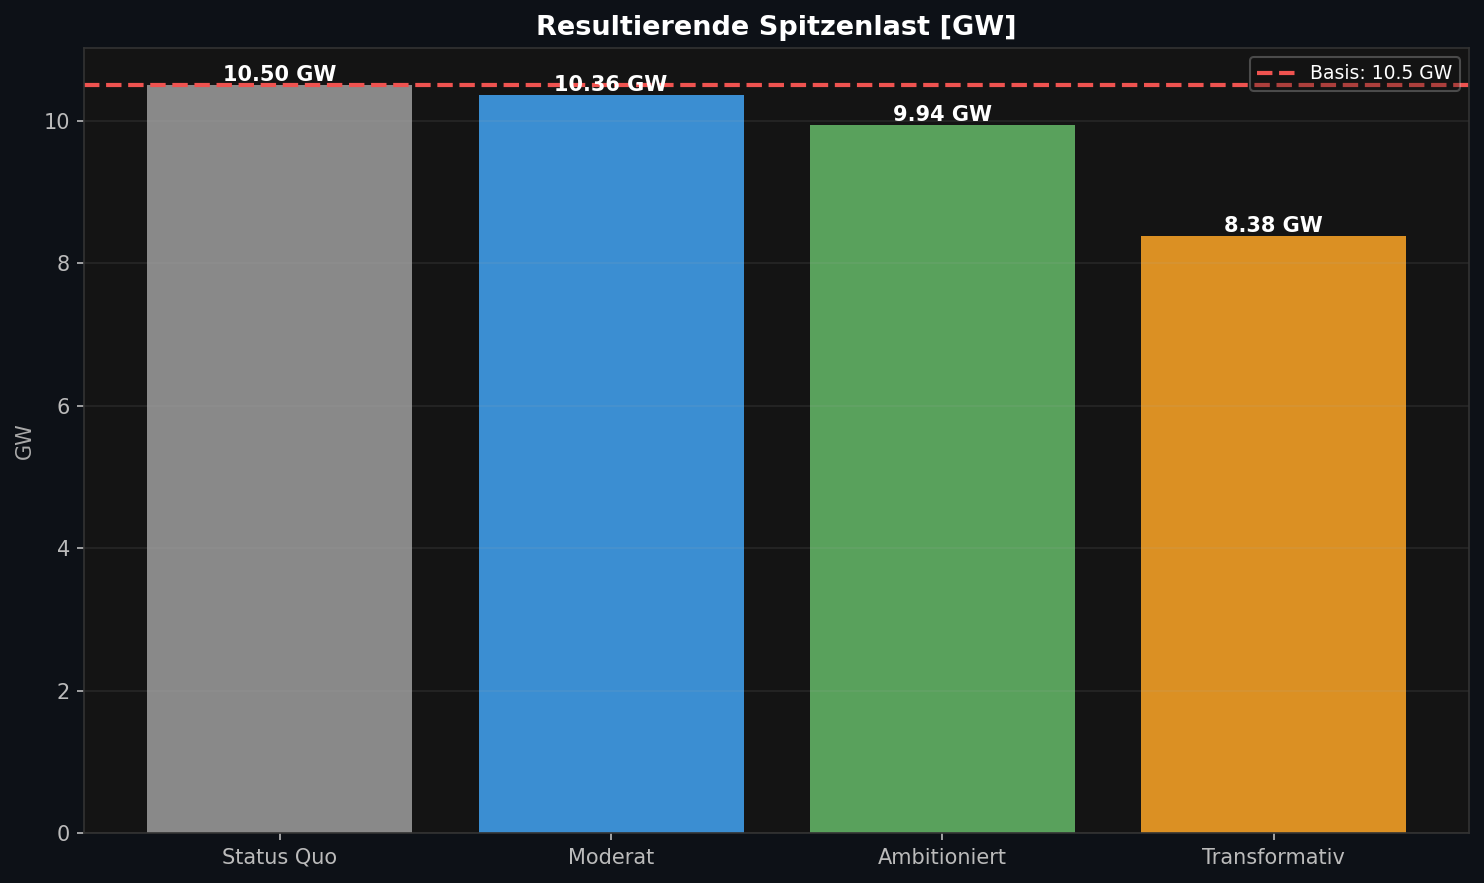


Resultierende Spitzenlast je Szenario [GW]



In [7]:
show_chart('nb03_spitzenlast.png',
           'Resultierende Spitzenlast je Szenario [GW]', width=800)

In [8]:
# Gleichzeitigkeit-Info aus den geladenen Szenarien
if _gz_mode != 'unbekannt':
    print(f'Gleichzeitigkeit (aus NB2): {_gz_mode} ({_gz_rate})')
    if _gz_mode == 'realistisch':
        print('  → 40% der Batterien dispatchen gleichzeitig (unkoordinierter Markt)')
        print('  → Zum Vergleich: optimistisch = 70% (VPP-koordiniert) ergibt ~1.75× höhere Entlastung')
    else:
        print('  → 70% der Batterien dispatchen gleichzeitig (VPP-koordinierter Dispatch)')
        print('  → Zum Vergleich: realistisch = 40% (unkoordiniert) ergibt ~0.57× der Entlastung')


Gleichzeitigkeit (aus NB2): realistisch (40%)
  → 40% der Batterien dispatchen gleichzeitig (unkoordinierter Markt)
  → Zum Vergleich: optimistisch = 70% (VPP-koordiniert) ergibt ~1.75× höhere Entlastung


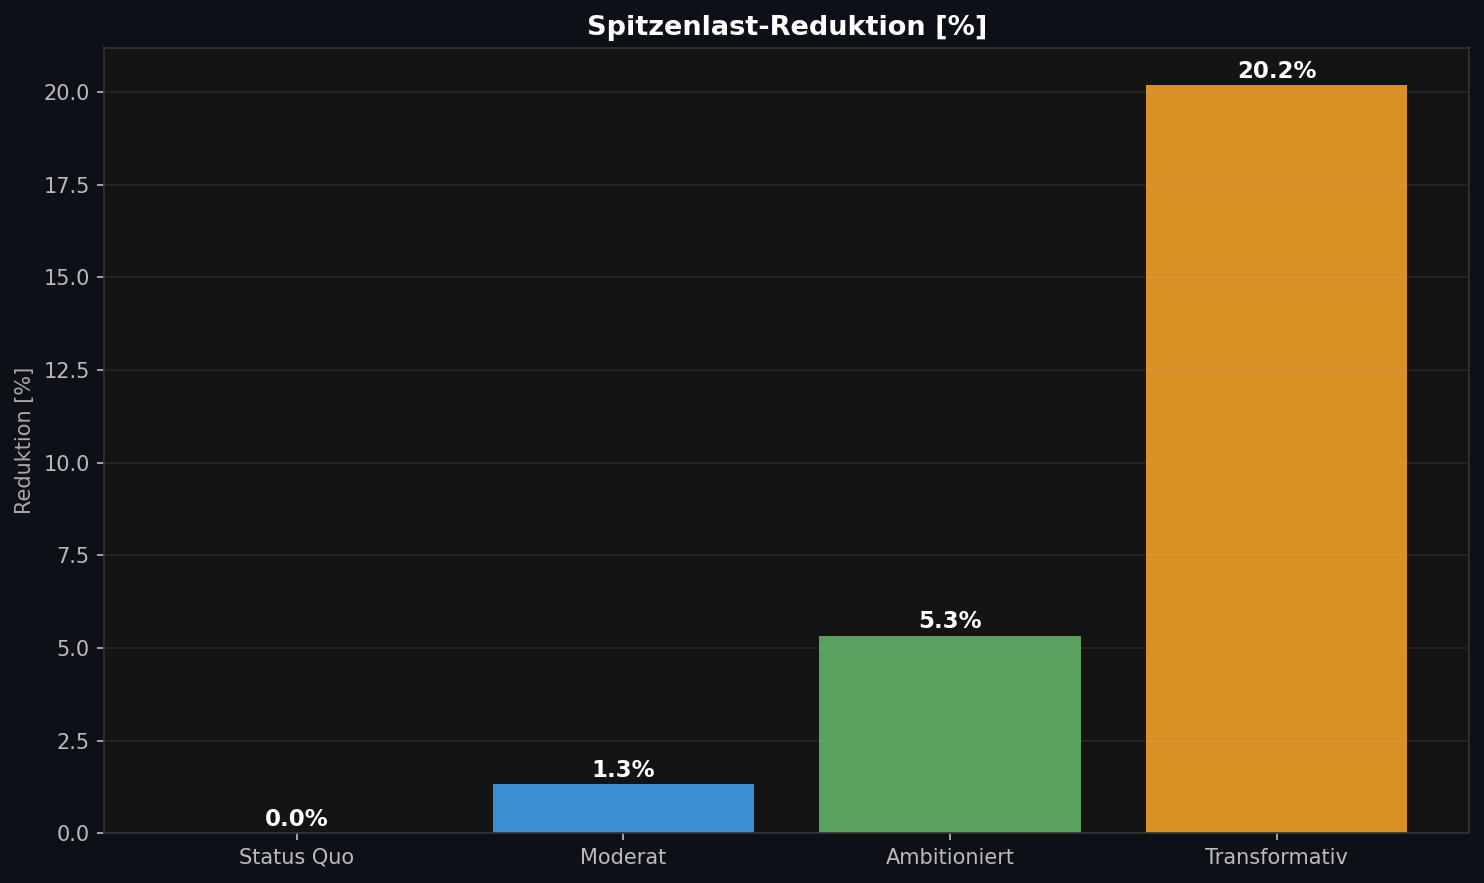


Spitzenlast-Reduktion [%] je Szenario



In [9]:
show_chart('nb03_spitzenlast_reduktion.png',
           'Spitzenlast-Reduktion [%] je Szenario', width=800)

### 4.5 Saisonale Rentabilität

Der Arbitrage-Spread variiert stark saisonal — entgegen der Erwartung ist **Frühling** die renditestärkste Saison, nicht Winter. Die Kombination aus noch hoher Heizlast und früher Solarproduktion erzeugt den grössten Intra-Tag-Preisunterschied.

| Saison | Ø Tages-Spread | Monatlicher Spread (Chart 5b) | Charakteristik |
|--------|---------------|-------------------------------|----------------|
| **Frühling** | ~139 EUR/MWh | Mai: 38 EUR/MWh (Maximum) | Höchste Arbitrage-Rendite |
| Sommer | ~122 EUR/MWh | Jul–Aug: 22–25 EUR/MWh | Viele Negativpreise (Ladechancen) |
| Winter | ~85 EUR/MWh | Jan–Mar: 19–20 EUR/MWh | Gleichmässiger, geringerer Spread |
| Herbst | ~81 EUR/MWh | Sep–Okt: 21–26 EUR/MWh | Übergangsphase |

**Negativpreise** treten hauptsächlich im Frühjahr/Sommer auf (Apr–Jun) — dort kann die Batterie kostenlos laden und erhöht damit den effektiven Erlös. Im Winter sind Negativpreise selten.


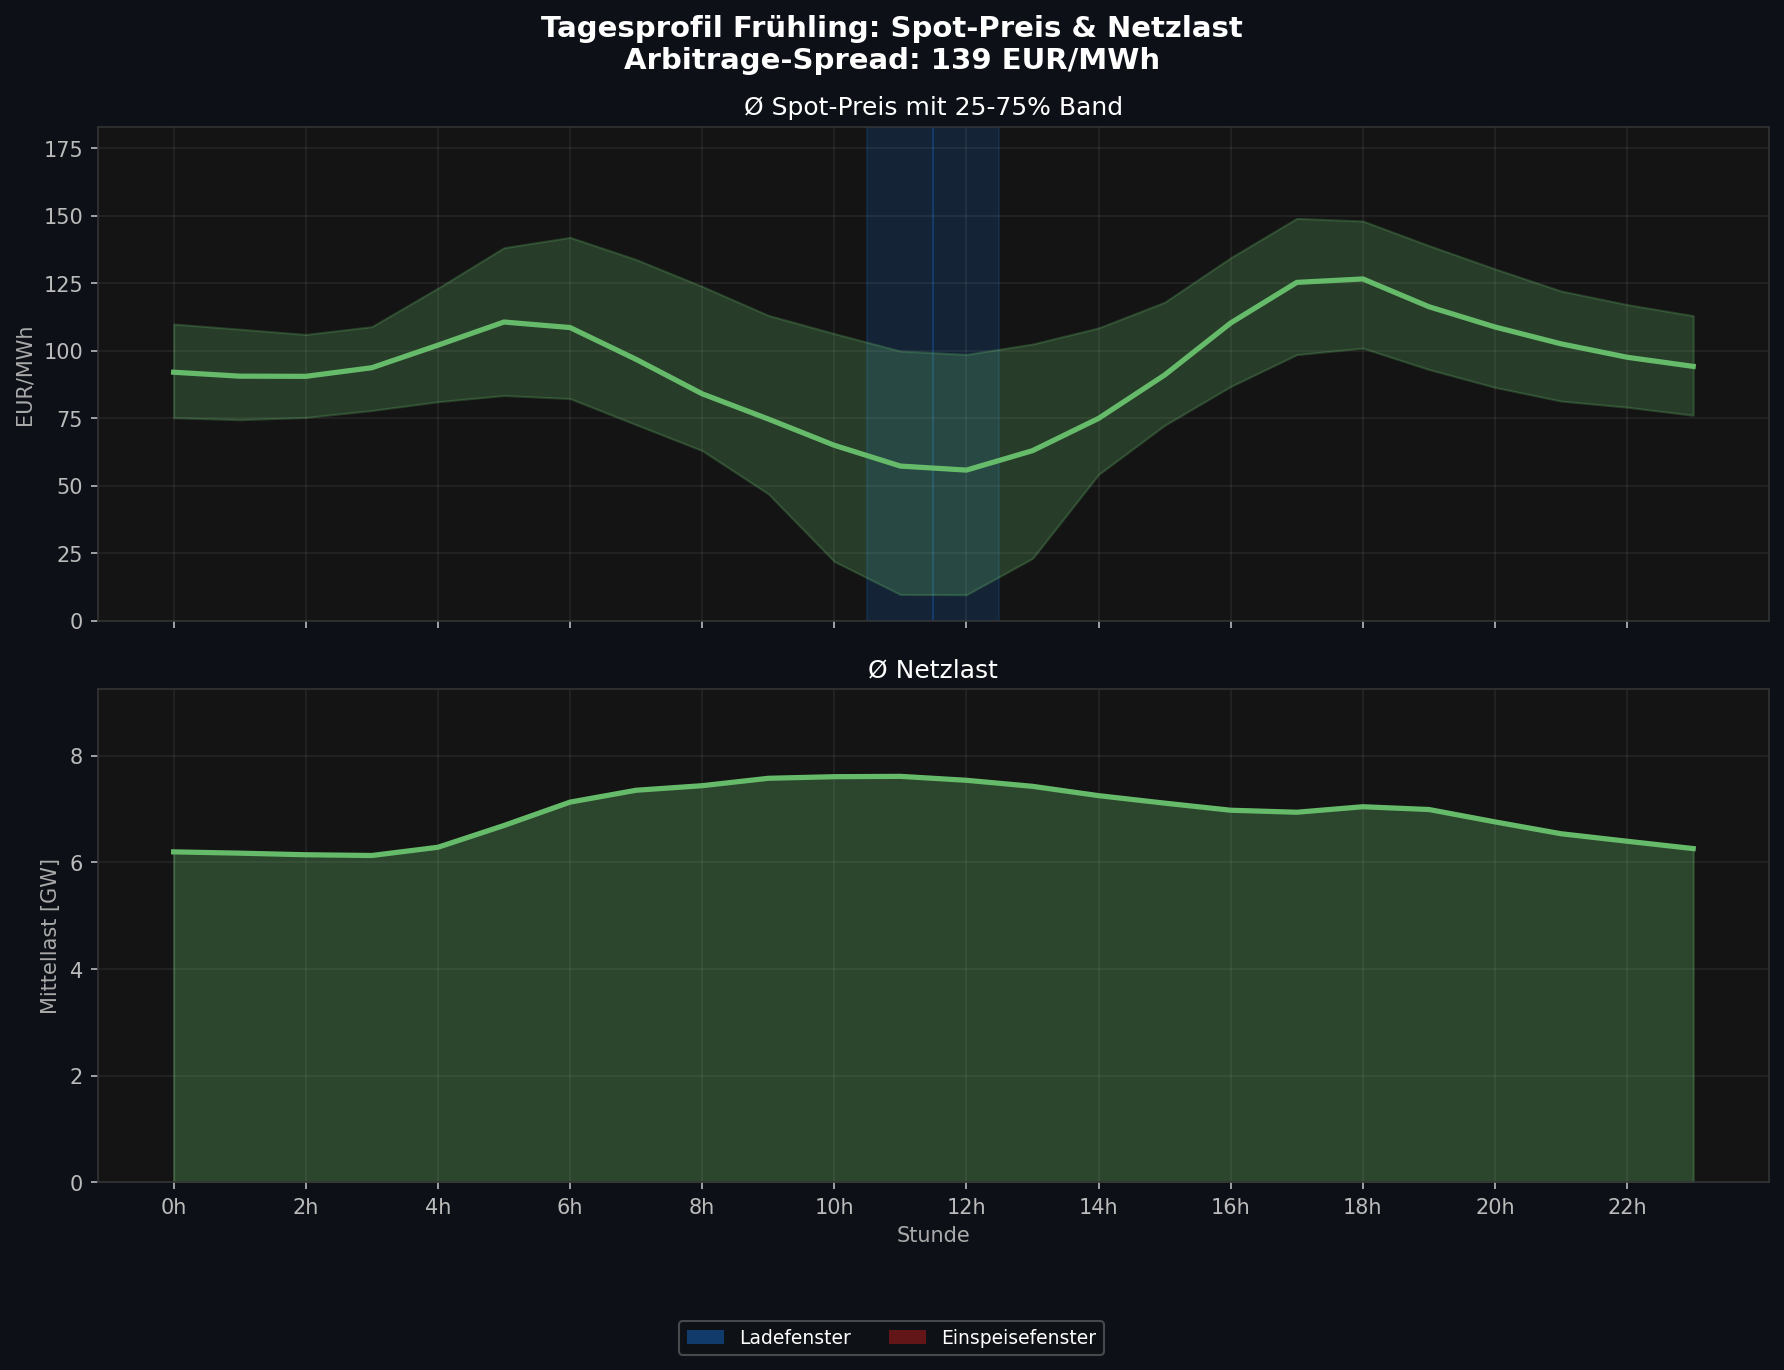


Frühling-Tagesprofil: Höchster Spread (139 EUR/MWh) — optimale Arbitrage-Bedingungen



In [10]:
show_chart('nb03_saisonal_frühling.png',
           'Frühling-Tagesprofil: Höchster Spread (139 EUR/MWh) — optimale Arbitrage-Bedingungen', width=900)

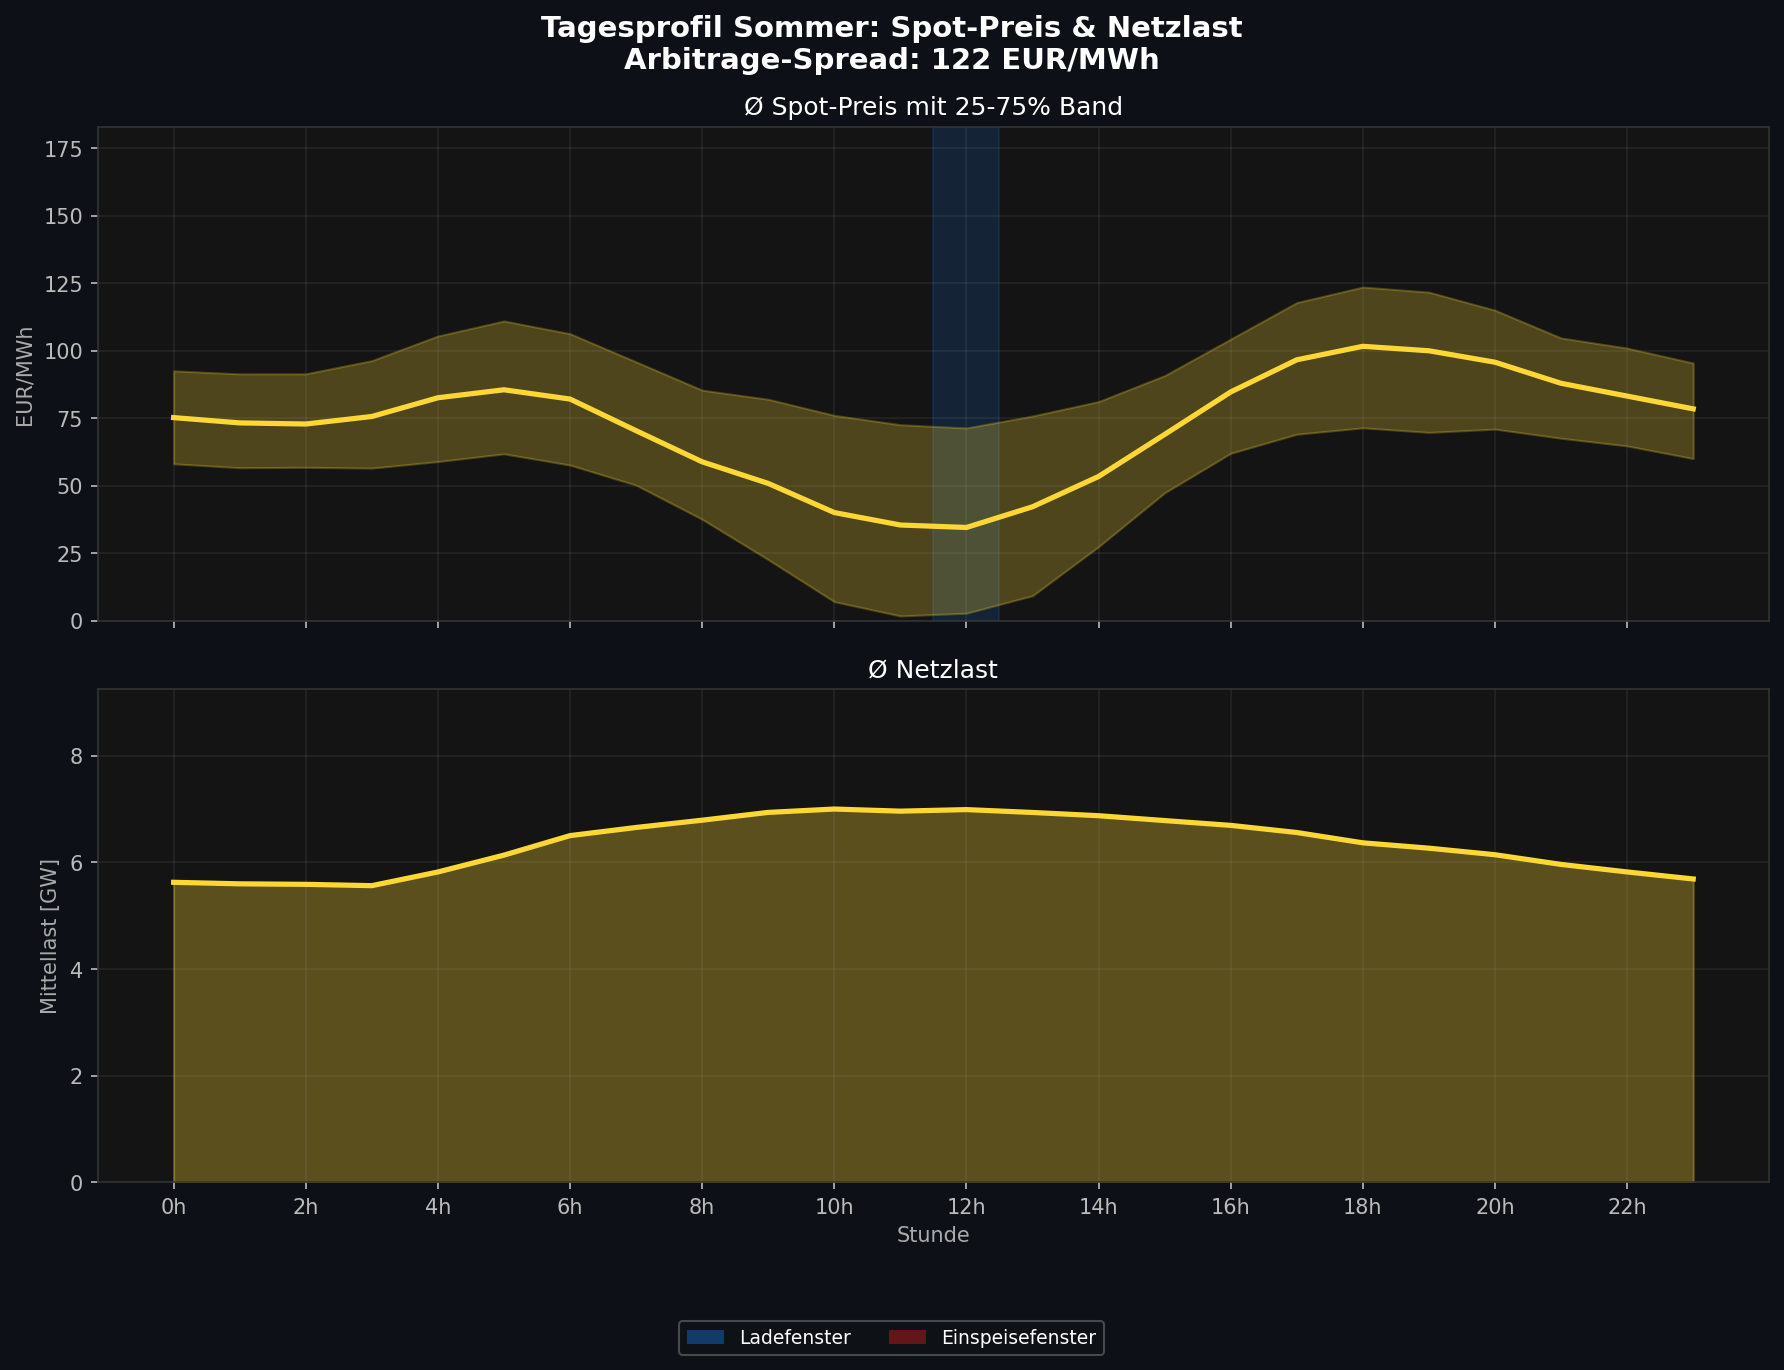


Sommer-Tagesprofil: Solar-Mittagstief erzeugt Negativpreise — kostenlose Ladezyklen



In [11]:
show_chart('nb03_saisonal_sommer.png',
           'Sommer-Tagesprofil: Solar-Mittagstief erzeugt Negativpreise — kostenlose Ladezyklen', width=900)

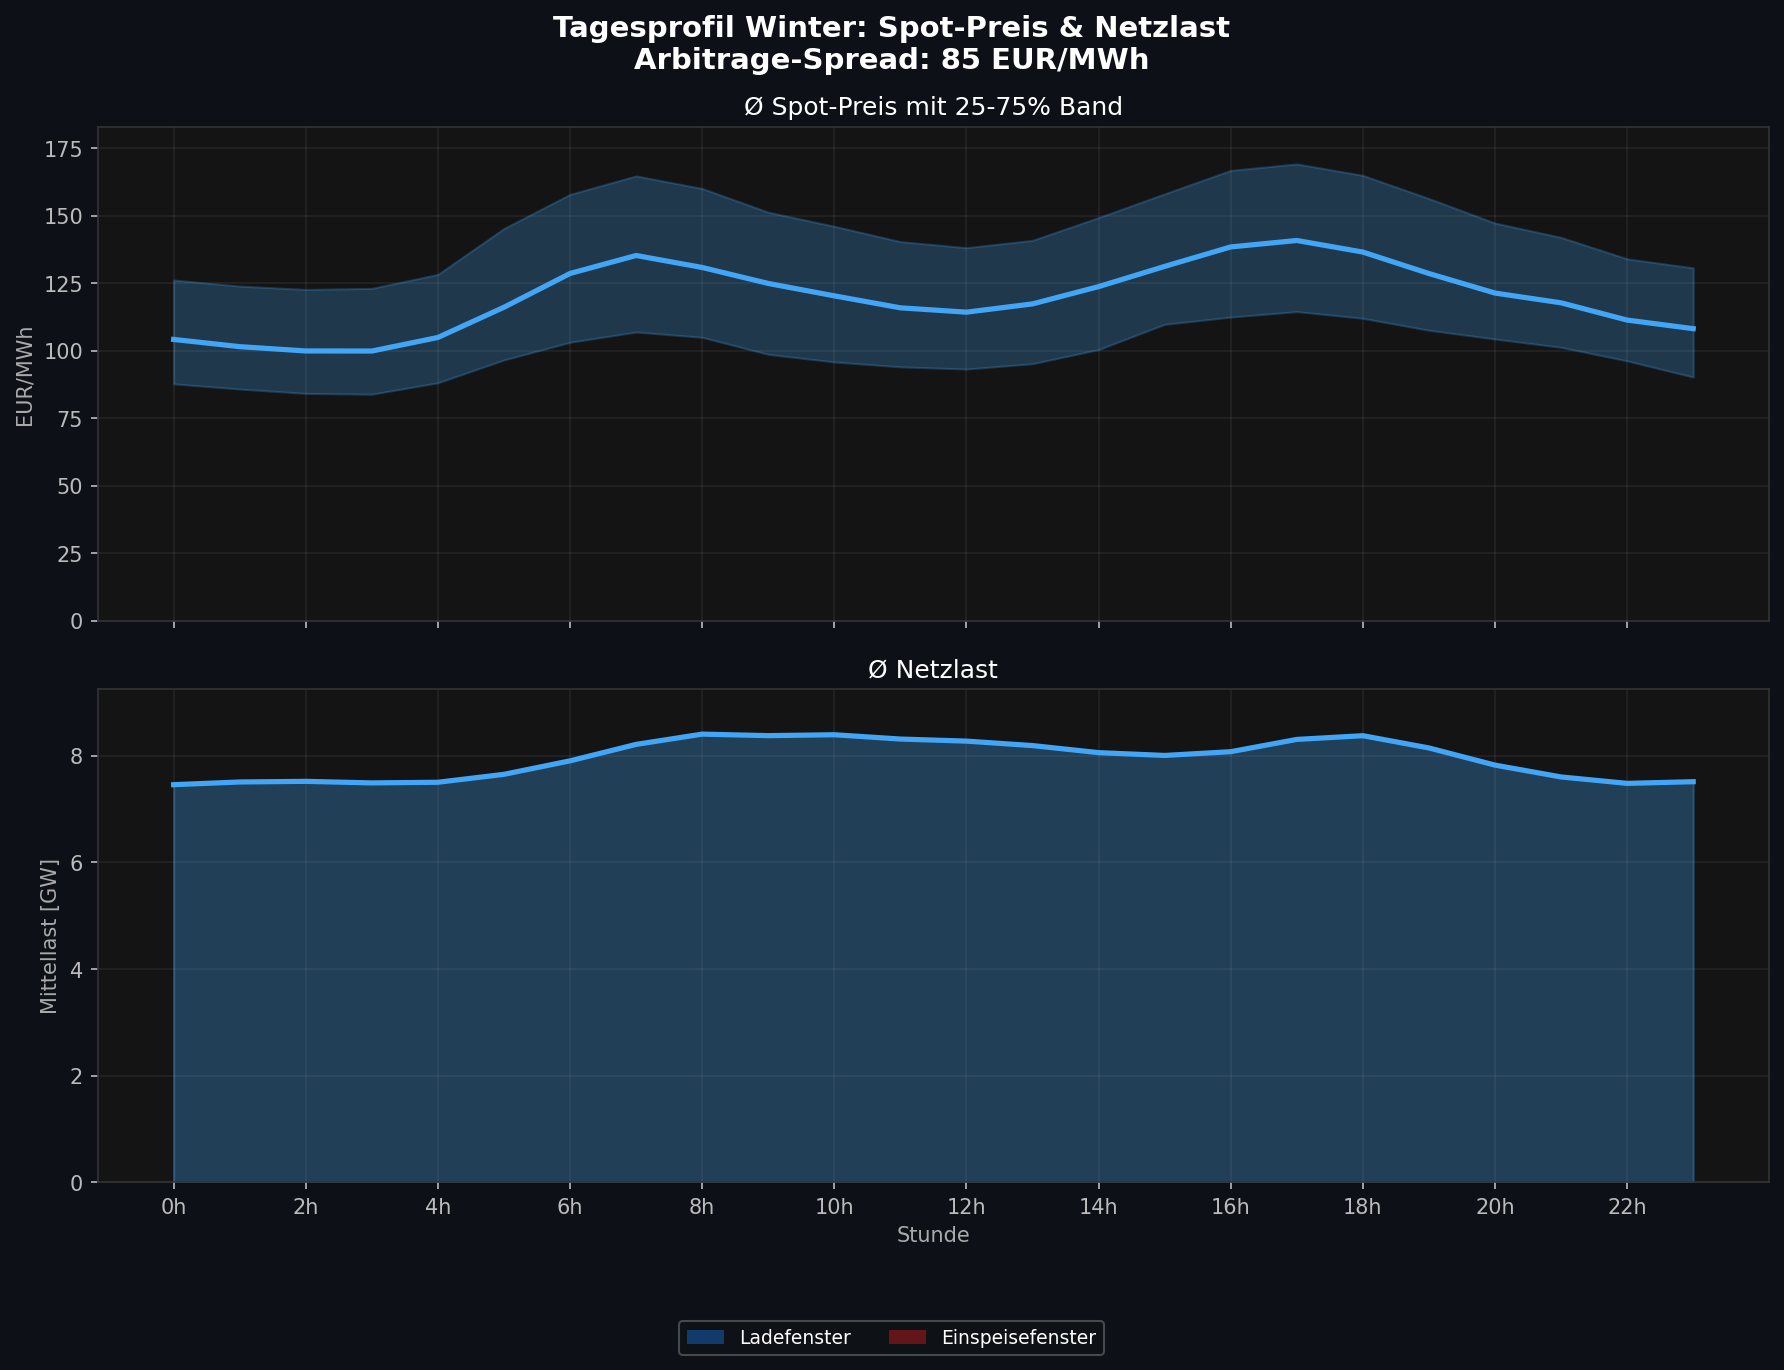


Winter-Tagesprofil: Geringster Spread (85 EUR/MWh) — Kontrastbeispiel zur renditeschwächsten Saison



In [12]:
show_chart('nb03_saisonal_winter.png',
           'Winter-Tagesprofil: Geringster Spread (85 EUR/MWh) — Kontrastbeispiel zur renditeschwächsten Saison', width=900)

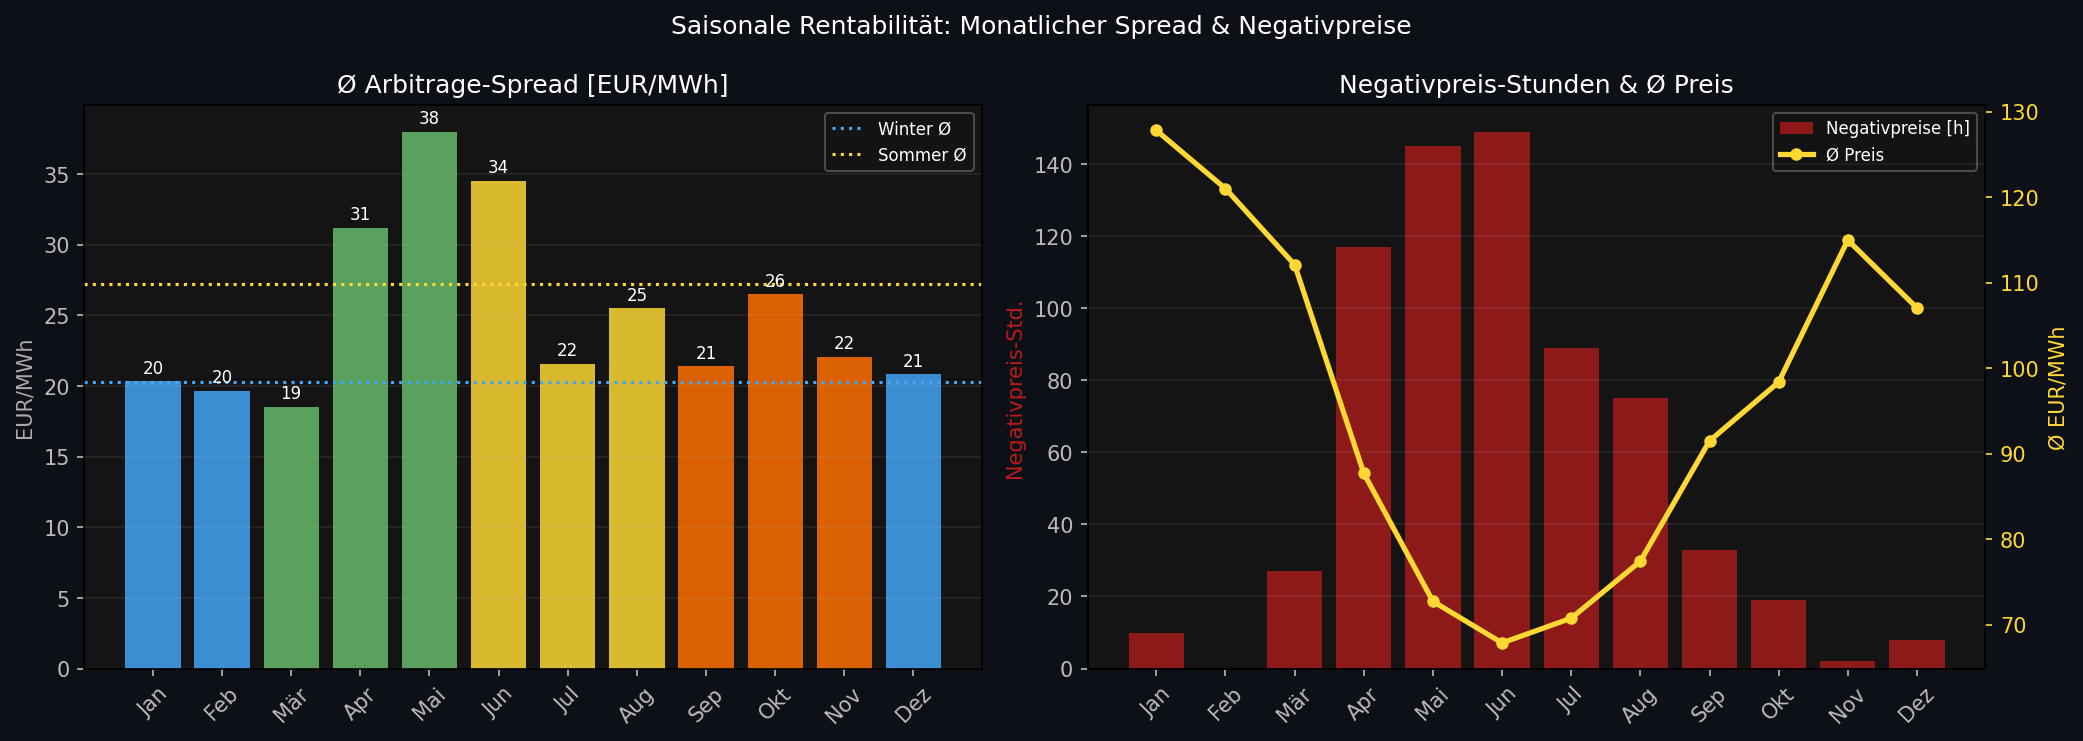


Monatlicher Arbitrage-Spread & Negativpreis-Stunden



In [13]:
show_chart('nb03_saisonal_roi.png',
           'Monatlicher Arbitrage-Spread & Negativpreis-Stunden', width=900)

---

### 4.6 Hinweis: Disruptive Parameter & Erweiterungen

Die oben gezeigten Ergebnisse basieren auf **reiner Grid-Arbitrage** bei aktuellen CH Day-Ahead-Preisen.
Folgende Parameter können den Business Case wesentlich verändern — sie werden in den Kür-Notebooks ab NB05 vertieft:

| Parameter | Einfluss | Kür-Notebook |
|-----------|----------|--------------|
| Spread-Entwicklung (steigend) | Direkter ROI-Treiber | [NB08 Marktdynamik](08_Marktdynamik.ipynb) |
| CAPEX-Lernkurve (−10%/Jahr) | Senkt Break-Even | [NB08 Marktdynamik](08_Marktdynamik.ipynb) |
| Erlösstacking (FCR/aFRR/VPP) | +400–600 EUR/Jahr bei 10 kWh | [NB09 Revenue Stacking](09_Revenue_Stacking.ipynb) |
| DA-optimaler Dispatch | +5–15% Erlössteigerung | [NB10 Dispatch-Optimierung](10_Dispatch_Optimierung.ipynb) |
| Standortwahl nach BVI | +30–60% Netzentlastungswert | [NB06 Räumliche Analyse](06_Raeumliche_Analyse.ipynb) |
| Empirische Validierung (Import/Export) | Bestätigt Business Case | [NB07 Cross-Border](07_Cross_Border.ipynb) |
| Konverter-Leistung (C-Rate) | Grösserer Konverter → mehr Erlös bei kurzen Preis-Tiefs | [NB10 Dispatch-Optimierung](10_Dispatch_Optimierung.ipynb) |
| CAPEX-Entwicklung (1800 EUR/10 kWh) | Bei ~180 EUR/kWh dramatisch besserer Break-Even | [NB08 Marktdynamik](08_Marktdynamik.ipynb) |
| Andere Batterietypen (LFP, Redox-Flow) | Längere Lebensdauer verändert Wirtschaftlichkeit | NB11 Technologievergleich *(geplant)* |
| Alternative Speicher (CAES, Pumpspeicher) | Andere Kostenstruktur, andere Regulierung | NB12 Alternative Speicher *(geplant)* |

> Die vollständige strategische Antwort auf die Forschungsfrage — unter welchen Bedingungen
> Grid-Arbitrage wirtschaftlich sinnvoll ist — liefert [NB05 Business Strategy](05_Business_Strategy.ipynb).


## 5. Fazit und Empfehlungen

**Grid-Arbitrage ist technisch realisierbar, bei aktuellen CH Marktpreisen aber noch nicht rentabel.** Kein Segment erreicht den Ziel-ROI von 5% p.a. durch reine Arbitrage:

| Segment | ROI (Arbitrage) | Break-Even | Bewertung |
|---------|----------------|------------|-----------|
| Privat 10 kWh | 0.6% | > 20 Jahre | Nicht rentabel |
| Gewerbe 100 kWh | 1.4% | > 20 Jahre | Nicht rentabel |
| Industrie 1 MWh | 2.3% | > 20 Jahre | Nächste am Ziel |
| Utility 10 MWh | 1.3% | > 20 Jahre | Nicht rentabel |

**Hauptursache:** Der Schweizer Day-Ahead Spread (~20–38 EUR/MWh je Monat) ist zu gering um CAPEX von 180–400 EUR/kWh in der modellierten Lebensdauer zurückzuverdienen.

**Wann kippt der Business Case?** Die Schwellenwerte sind in Abschnitt 4.6 aufgeführt — unter anderem steigender Spread, sinkende CAPEX und Erlösstacking. Eine vollständige Szenarienanalyse liefert [NB05 Business Strategy](05_Business_Strategy.ipynb).

> Weiterführende strategische Empfehlungen und räumliche Optimierung: → [NB05 Business Strategy](05_Business_Strategy.ipynb)

---
*Daten: ENTSO-E Transparency Platform (DL-DE-BY-2.0) · ENTSO-E query\_load (Netzlast).*  
*Kür-Analysen (NB05–NB10): Marktdynamik, Erlösstacking, Dispatch-Optimierung, räumliche Analyse.*


---

## 6. Kür-Erweiterungen

Die folgenden Notebooks vertiefen den Business Case um weitere Dimensionen.
Sie sind eigenständig lauffähig und setzen NB01–NB04 voraus.

| Notebook | Thema | Status |
|----------|-------|--------|
| [NB05 Business Strategy](05_Business_Strategy.ipynb) | Trigger-Matrix, Kombinations-Szenarien, Synthese | 🔄 in Arbeit |
| [NB06 Räumliche Analyse](06_Raeumliche_Analyse.ipynb) | BVI, Zonenbilanzen, Standortoptimierung | 🔄 in Arbeit |
| [NB07 Cross-Border](07_Cross_Border.ipynb) | Grenzflüsse, Import/Export-Validierung | 🔄 in Arbeit |
| [NB08 Marktdynamik](08_Marktdynamik.ipynb) | Spread-Trend, CAPEX-Lernkurve | 🔄 in Arbeit |
| [NB09 Revenue Stacking](09_Revenue_Stacking.ipynb) | VPP, FCR/aFRR, Smart Tariff | 🔄 in Arbeit |
| [NB10 Dispatch-Optimierung](10_Dispatch_Optimierung.ipynb) | DA-optimal vs. reaktiv | 🔄 in Arbeit |
| [NB11 Technologievergleich](11_Technologievergleich.ipynb) | LFP / NMC / Redox-Flow / NaS | 🔄 in Arbeit |
| [NB12 Alternative Speicher](12_Alternative_Speicher.ipynb) | Pumpspeicher, CAES, Power-to-X | 🔄 in Arbeit |
| [NB13 Eigenverbrauchsopt.](13_Eigenverbrauch.ipynb) | Netz laden → Eigenverbrauch statt Einspeisung | 🔄 in Arbeit |
| [NB14 Produktsteckbrief](14_Produkt_Steckbrief.ipynb) | Konkretes Produkt 7 kW / 14 kWh / 2 000 EUR | 🔄 in Arbeit |


In [14]:
# ── Abschluss-Übersicht ──────────────────────────────────────────────────────
import os

MODE       = CFG.get('mode', 'data')
DIR_RAW    = os.path.join('data', 'raw')
DIR_PROC   = os.path.join('data', 'processed')
DIR_INTER  = os.path.join('data', 'intermediate', SZ_AKTIV)

print('=' * 60)
print(f'NB04 – Abschluss  |  Szenario: {SZ_AKTIV}')
print('=' * 60)

print('\nNotebooks (Pflicht):')
for nb_name in ['01_Daten_Laden.ipynb','02_Daten_Analyse.ipynb',
                '03_Visualisierungen.ipynb','04_Business_Case.ipynb']:
    print(f'  {"✅" if os.path.exists(nb_name) else "❌"}  {nb_name}')

print(f'\nZwischenergebnisse ({DIR_INTER}):')
if os.path.exists(DIR_INTER):
    for f in sorted(os.listdir(DIR_INTER)):
        kb = os.path.getsize(os.path.join(DIR_INTER, f)) / 1024
        print(f'  ✅  {f:<45} {kb:>7.1f} KB')
else:
    print(f'  ❌  Ordner nicht vorhanden — NB02 ausführen')

print(f'\nCharts ({CHARTS_DIR}):')
if os.path.exists(CHARTS_DIR):
    pngs = sorted(f for f in os.listdir(CHARTS_DIR) if f.endswith('.png'))
    for f in pngs:
        print(f'  ✅  {f}')
    print(f'  {len(pngs)} Chart(s) vorhanden')
else:
    print(f'  ❌  Ordner nicht vorhanden — NB03 ausführen')

print(f'\n→ Weiter mit: NB05 Business Strategy (Kür)')


NB04 – Abschluss  |  Szenario: realistisch

Notebooks (Pflicht):
  ✅  01_Daten_Laden.ipynb
  ✅  02_Daten_Analyse.ipynb
  ✅  03_Visualisierungen.ipynb
  ✅  04_Business_Case.ipynb

Zwischenergebnisse (data\intermediate\realistisch):
  ✅  netzentlastung_szenarien.csv                      0.4 KB
  ✅  wirtschaftlichkeit.csv                            0.5 KB

Charts (output\charts\realistisch):
  ✅  chart09a_stacking_erloese.png
  ✅  chart09b_breakeven_vergleich.png
  ✅  chart7a_spread_trend.png
  ✅  chart7b_volatilitaet.png
  ✅  kuer_nb06_anim_4zeitpunkte.png
  ✅  kuer_nb06_bvi_heatmap.png
  ✅  kuer_nb06_bvi_jahresdurchschnitt.png
  ✅  kuer_nb06_bvi_saisonal.png
  ✅  kuer_nb06_heatmap_lastprofil.png
  ✅  kuer_nb06_heatmap_produktionsmix.png
  ✅  kuer_nb06_karte_engpaesse.png
  ✅  kuer_nb06_karte_erzeuger.png
  ✅  kuer_nb06_karte_verbrauchszentren.png
  ✅  kuer_nb06_karte_zonenimbalance.png
  ✅  kuer_nb06_rollout_spatial.png
  ✅  kuer_nb06_zonenimbalance_saisonal.png
  ✅  kuer_nb07_import_ex

---
| [← NB03 Visualisierungen](03_Visualisierungen.ipynb) | [↑ Projektübersicht](00_Project_Overview.ipynb) | [→ NB05 Business Strategy](05_Business_Strategy.ipynb) |
|:---|:---:|---:|
